# Life Expectancy at Birth in Historical China: Multi-Source Evidence

Supporting evidence for the Shifting Baseline Syndrome (SBS) manuscript.  
This notebook visualises $e_0$ estimates from **different historical data sources**
(genealogies, banner registers, imperial lineage records, retrospective surveys,
and modern national statistics) to show the remarkably stable ~30–40 year plateau
that constrained generational memory throughout the study period.

**Key point for SBS**: The optimal sliding-window width (~30 years) found in the
correlation analysis matches the **typical lifespan** — the living memory horizon
of a single generation — regardless of which historical source is consulted.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import numpy as np
from pathlib import Path

plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": 11,
        "axes.linewidth": 0.8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.dpi": 150,
    }
)

DATA = Path("..") / "data"
OUT = Path("results")

In [2]:
china = pd.read_csv(DATA / "life_expectancy_china.csv")
globe = pd.read_csv(DATA / "life_expectancy_global.csv")


# ── assign each Chinese record to a source category ────────────────
def assign_category(row):
    src = row["source"]
    dt = row["data_type"]
    if "OWID" in src:
        return "Modern national estimate (OWID)"
    elif "Barclay" in src:
        return "Retrospective survey (Barclay & Coale 1976)"
    elif dt == "Genealogy":
        return "Genealogy (Telford 1990)"
    elif dt == "Banner register":
        return "Banner register (Lee & Campbell)"
    elif dt == "Imperial lineage":
        return "Imperial lineage (Lee et al. 1994)"
    else:
        return "Other"


china["category"] = china.apply(assign_category, axis=1)
print(china.groupby("category").size())
china

category
Banner register (Lee & Campbell)               6
Genealogy (Telford 1990)                       5
Imperial lineage (Lee et al. 1994)             1
Modern national estimate (OWID)                4
Retrospective survey (Barclay & Coale 1976)    1
dtype: int64


,year,e0,source,data_type,region,note,category
0,1400,32,Telford (1990),Genealogy,Anhui,Tongcheng lineages; e20-based e0 estimate with...,Genealogy (Telford 1990)
1,1500,34,Telford (1990),Genealogy,Anhui,Tongcheng lineages,Genealogy (Telford 1990)
2,1600,33,Telford (1990),Genealogy,Anhui,Tongcheng lineages,Genealogy (Telford 1990)
3,1700,35,Telford (1990),Genealogy,Anhui,Tongcheng lineages,Genealogy (Telford 1990)
4,1750,34,Lee et al. (1994),Imperial lineage,National elite,Qing imperial clan,Imperial lineage (Lee et al. 1994)
5,1787,37,Lee & Campbell (1997),Banner register,Liaoning,1774-1799 midpoint; CMGPD-LN,Banner register (Lee & Campbell)
6,1800,36,Telford (1990),Genealogy,Anhui,Tongcheng lineages,Genealogy (Telford 1990)
7,1812,38,Lee & Campbell (1997),Banner register,Liaoning,1800-1824 midpoint; CMGPD-LN,Banner register (Lee & Campbell)
8,1837,36,Lee & Campbell (1997),Banner register,Liaoning,1825-1849 midpoint; CMGPD-LN,Banner register (Lee & Campbell)
9,1862,37,Lee & Campbell (1997),Banner register,Liaoning,1850-1873 midpoint; CMGPD-LN,Banner register (Lee & Campbell)


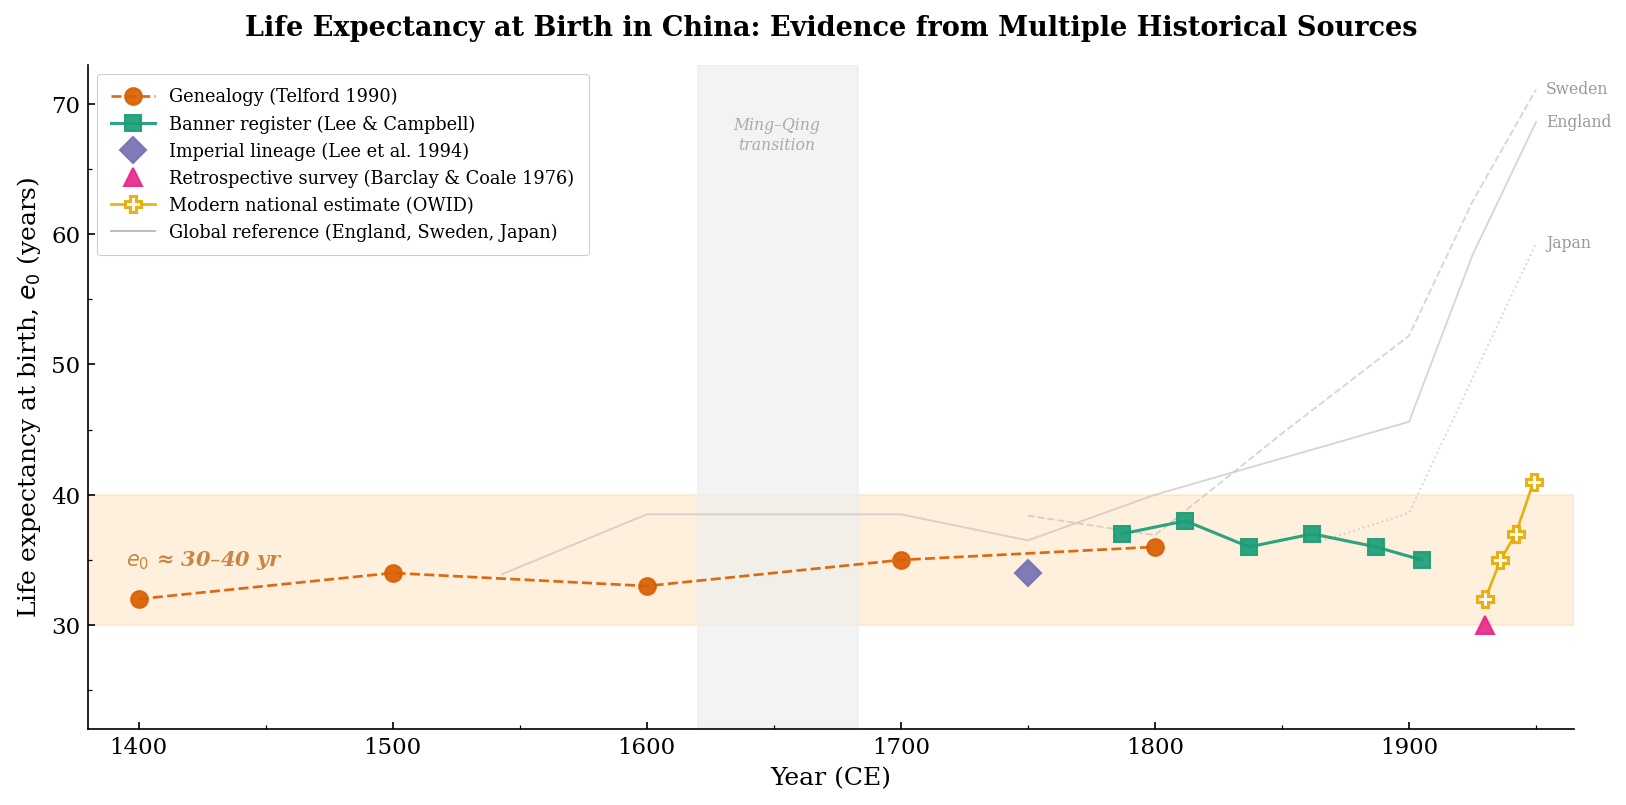

Saved → reports/results/life_expectancy_timeseries.{png,pdf}


In [3]:
# ══════════════════════════════════════════════════════════════════════
# MAIN FIGURE — Chinese multi-source focus
# ══════════════════════════════════════════════════════════════════════

# ── source style definitions ──────────────────────────────────────────
SRC_STYLE = {
    "Genealogy (Telford 1990)": dict(
        color="#D95F02",
        marker="o",
        ms=8,
        ls="--",
        lw=1.3,
        mfc="#D95F02",
        mec="#D95F02",
        zorder=5,
    ),
    "Banner register (Lee & Campbell)": dict(
        color="#1B9E77",
        marker="s",
        ms=8,
        ls="-",
        lw=1.5,
        mfc="#1B9E77",
        mec="#1B9E77",
        zorder=6,
    ),
    "Imperial lineage (Lee et al. 1994)": dict(
        color="#7570B3",
        marker="D",
        ms=9,
        ls="none",
        lw=0,
        mfc="#7570B3",
        mec="#7570B3",
        zorder=6,
    ),
    "Retrospective survey (Barclay & Coale 1976)": dict(
        color="#E7298A",
        marker="^",
        ms=9,
        ls="none",
        lw=0,
        mfc="#E7298A",
        mec="#E7298A",
        zorder=5,
    ),
    "Modern national estimate (OWID)": dict(
        color="#E6AB02",
        marker="P",
        ms=8,
        ls="-",
        lw=1.3,
        mfc="white",
        mec="#E6AB02",
        mew=1.5,
        zorder=5,
    ),
}

fig, ax = plt.subplots(figsize=(11, 5.5))

# ── background: 30–40 yr band ─────────────────────────────────────────
ax.axhspan(30, 40, color="#FDD49E", alpha=0.35, zorder=0, label="_nolegend_")
ax.text(
    1395,
    35,
    "$e_0$ ≈ 30–40 yr",
    fontsize=10,
    color="#B35900",
    fontstyle="italic",
    va="center",
    fontweight="bold",
    alpha=0.7,
)

# ── background: global reference (thin grey) ──────────────────────────
for country, ls in [("England", "-"), ("Sweden", "--"), ("Japan", ":")]:
    sub = globe[globe["country"] == country].sort_values("year")
    ax.plot(
        sub["year"],
        sub["e0"],
        color="#BBBBBB",
        linewidth=0.9,
        linestyle=ls,
        zorder=1,
        alpha=0.6,
    )
    # label at the end of each line
    last = sub.iloc[-1]
    ax.text(
        last["year"] + 4,
        last["e0"],
        country,
        fontsize=7.5,
        color="#999999",
        va="center",
    )

# ── Ming-Qing transition shading ─────────────────────────────────────
ax.axvspan(1620, 1683, color="#EEEEEE", alpha=0.7, zorder=0)
ax.text(
    1651,
    69,
    "Ming–Qing\ntransition",
    fontsize=7.5,
    ha="center",
    va="top",
    color="#AAAAAA",
    fontstyle="italic",
)

# ── plot each Chinese source category ─────────────────────────────────
for cat, sty in SRC_STYLE.items():
    sub = china[china["category"] == cat].sort_values("year")
    if sub.empty:
        continue
    kw = dict(
        marker=sty["marker"],
        markersize=sty["ms"],
        color=sty["color"],
        linewidth=sty["lw"],
        linestyle=sty["ls"],
        markerfacecolor=sty.get("mfc", sty["color"]),
        markeredgecolor=sty.get("mec", sty["color"]),
        markeredgewidth=sty.get("mew", 1.0),
        zorder=sty["zorder"],
        alpha=0.92,
        label=cat,
    )
    ax.plot(sub["year"], sub["e0"], **kw)

# ── annotate the ~30-yr scale bar ─────────────────────────────────────
bar_y = 24.5
bar_x0, bar_x1 = 1470, 1500
# ax.annotate('', xy=(bar_x0, bar_y), xytext=(bar_x1, bar_y),
#             arrowprops=dict(arrowstyle='<->', color='#333333', lw=1.5))
# ax.text((bar_x0 + bar_x1) / 2, bar_y - 1.5,
#         '~30 yr  (≈ one generation)', fontsize=9, ha='center',
#         va='top', color='#333333', fontweight='bold')

# ── axes ───────────────────────────────────────────────────────────────
ax.set_xlim(1380, 1965)
ax.set_ylim(22, 73)
ax.set_xlabel("Year (CE)", fontsize=12)
ax.set_ylabel("Life expectancy at birth, $e_0$ (years)", fontsize=12)
ax.xaxis.set_major_locator(mticker.MultipleLocator(100))
ax.xaxis.set_minor_locator(mticker.MultipleLocator(50))
ax.yaxis.set_major_locator(mticker.MultipleLocator(10))
ax.yaxis.set_minor_locator(mticker.MultipleLocator(5))
ax.tick_params(which="both", direction="in")

# ── legend ─────────────────────────────────────────────────────────────
# Build legend: Chinese sources + one entry for global reference
handles, labels = ax.get_legend_handles_labels()
# add a grey line for "Global reference"
global_handle = mlines.Line2D(
    [],
    [],
    color="#BBBBBB",
    linewidth=0.9,
    label="Global reference (England, Sweden, Japan)",
)
handles.append(global_handle)
labels.append(global_handle.get_label())

leg = ax.legend(
    handles,
    labels,
    loc="upper left",
    frameon=True,
    framealpha=0.95,
    fontsize=8.5,
    edgecolor="#CCCCCC",
    handlelength=2.5,
    borderpad=0.8,
)
leg.get_frame().set_linewidth(0.5)

# ── title ──────────────────────────────────────────────────────────────
ax.set_title(
    "Life Expectancy at Birth in China: Evidence from Multiple Historical Sources",
    fontsize=13,
    fontweight="bold",
    pad=14,
)

fig.tight_layout()
fig.savefig(OUT / "life_expectancy_timeseries.png", dpi=300, bbox_inches="tight")
fig.savefig(OUT / "life_expectancy_timeseries.pdf", bbox_inches="tight")
plt.show()
print("Saved → reports/results/life_expectancy_timeseries.{png,pdf}")

## Interpretation for SBS

The figure shows that **regardless of the data source** — genealogies
(Anhui), Qing banner registers (Liaoning), imperial lineage records,
retrospective surveys, or modern national estimates — life expectancy
at birth remained within a narrow **30–40 year band** throughout the
Ming–Qing period (1368–1912).

This multi-source convergence strengthens the argument that:

1. **A generation's living memory** was approximately **~30 years** —
   consistent with the optimal sliding-window width found in our
   correlation analysis.

2. The result is **robust across source types**: elite lineages,
   Manchurian bannermen, Han gentry, and 20th-century rural populations
   all point to the same plateau.

3. The grey reference lines show that pre-industrial Europe shared a
   similar baseline before ~1800, suggesting the generational memory
   constraint is a **universal pre-industrial phenomenon**, not a
   China-specific artefact.

## Data Sources

| Source | Material | Region | DOI |
|--------|----------|--------|-----|
| Telford (1990), *Late Imperial China* | Tongcheng genealogies, 1300–1880 | Anhui | 10.1353/late.1990.0008 |
| Lee & Campbell (1997), *Fate and Fortune* | Liaoning banner registers, 1774–1873 | Liaoning | 10.1017/cbo9780511563058 |
| Campbell & Lee (2009), *Soc. Sci. Med.* | Liaoning banner registers, 1749–1909 | Liaoning | 10.1016/j.socscimed.2009.02.017 |
| Lee et al. (1994), *Population Studies* | Qing imperial clan | National (elite) | 10.1080/0032472031000147936 |
| Barclay, Coale et al. (1976), *Pop. Index* | 1930s rural survey back-projection | National (rural) | 10.2307/2734378 |
| Bengtsson, Campbell & Lee (2004) | Cross-national comparison | Multi-country | 10.7551/mitpress/4227.001.0001 |
| Our World in Data / Riley (2005) | Modern national estimates | National | ourworldindata.org |